In [1]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
import esm2quinox
import jax.random as jrandom
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dataset import Dataset_PEPBI
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader

import numpy as np
import pandas as pd

In [2]:
base_path = '/home/kunzj'

### three way ~ original

ERROR:2025-12-11 13:48:30,723:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/kunzj/miniforge3/envs/BindCraft_modified/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/kunzj/miniforge3/envs/BindCraft_modified/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/kunzj/miniforge3/envs/BindCraft_modified/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 281, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE


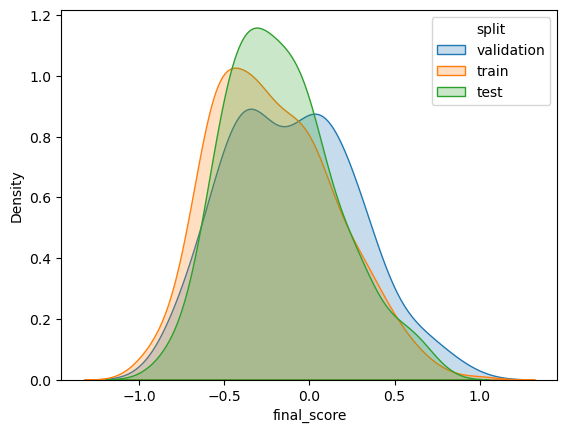

In [3]:
train_csv = pd.read_csv('../../data/ppi_affinity_dataset/raw/training.csv')
test_csv = pd.read_csv('../../data/ppi_affinity_dataset/raw/test.csv')
validation_csv = pd.read_csv('../../data/ppi_affinity_dataset/raw/validation.csv')

data_csv = {'train_csv':train_csv,
            'test_csv':test_csv,
            'validation_csv':validation_csv,
            }

new_df = {}
for idx in data_csv.keys():
    seq_prot = [x.split('-')[0] for x in list(data_csv[idx]['Sequence'])]
    seq_pept = [x.split('-')[1] for x in list(data_csv[idx]['Sequence'])]
    energies = data_csv[idx]['delta_G']
    new_df[idx] =pd.DataFrame({'Energy':energies,
                                 'Prot_Seq':seq_prot,
                                 'Pept_Seq':seq_pept})
new_df['train_csv'][['Energy']] = new_df['train_csv'][['Energy']] * -1
new_df['test_csv'][['Energy']] = new_df['test_csv'][['Energy']] * -1
new_df['validation_csv'][['Energy']] = new_df['validation_csv'][['Energy']] * -1
scaler = MinMaxScaler(feature_range=(-1,1))
new_df['train_csv']['Energy']= scaler.fit_transform(new_df['train_csv'][['Energy']])
new_df['validation_csv']['Energy']= scaler.transform(new_df['validation_csv'][['Energy']])
new_df['test_csv']['Energy']= scaler.transform(new_df['test_csv'][['Energy']])


for idx in new_df.keys():
    new_df[idx].to_csv(f'../../data/ppi_affinity_dataset/cosine_sim_scaled/three_way/{str(idx.split("_")[0])}.csv')
    
data_train = Dataset_PEPBI(
    columns=["Prot_Seq", "Pept_Seq", "Energy"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/ppi_affinity_dataset/cosine_sim_scaled/three_way/train.csv",
    transform=esm2quinox.tokenise,
)
train_loader = DataLoader(data_train, batch_size=20)

\
data_validation = Dataset_PEPBI(
    columns=["Prot_Seq", "Pept_Seq", "Energy"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/ppi_affinity_dataset/cosine_sim_scaled/three_way/validation.csv",
    transform=esm2quinox.tokenise,
)
validation_loader = DataLoader(data_validation, batch_size=1)

data_test = Dataset_PEPBI(
    columns=["Prot_Seq", "Pept_Seq", "Energy"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/ppi_affinity_dataset/cosine_sim_scaled/three_way/test.csv",
    transform=esm2quinox.tokenise,
)
test_loader = DataLoader(data_test, batch_size=1)

test_key_init = jrandom.PRNGKey(1)


sns.kdeplot(data_validation.aff_Vals, fill=True, label="validation")
sns.kdeplot(data_train.aff_Vals, fill=True, label="train")
sns.kdeplot(data_test.aff_Vals, fill=True, label="test")
plt.legend(title="split")
plt.xlabel("final_score")
plt.ylabel("Density")
plt.show()

<Axes: ylabel='Count'>

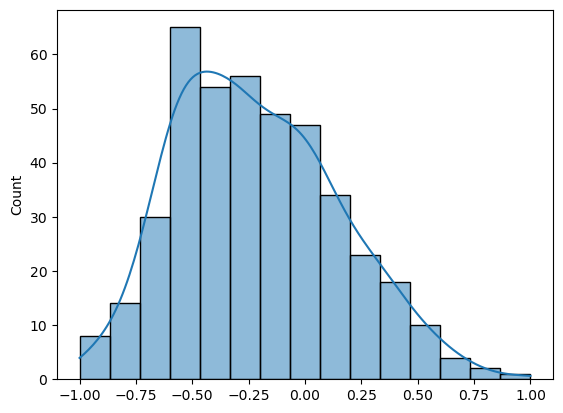

In [46]:
sns.histplot(data_train.aff_Vals, kde=True)

In [47]:
from typing import List, Union
def select_uniformly_distributed_subset_max_data(
    data: List[Union[int, float]],
    num_bins: int
) -> List[Union[int, float]]:
    """
    Selects a subset of values by binning the data range.
    It attempts to use 'num_bins' bins across the data range 
    and selects the value closest to the center of each bin that 
    *actually contains data*. This ensures good uniformity while 
    using the maximum number of available "uniform slots" (bins).

    Args:
        data: The input list of numerical values.
        num_bins: The desired number of uniform slots (bins) across the range. 
                  This determines the 'good' uniformity spacing.

    Returns:
        A list containing the selected values, with a length <= num_bins.
    """
    
    # 1. Input Validation and Preparation (Safe against Series/Array input)
    if len(data) == 0 or num_bins <= 0:
        return []

    np_data = np.array(data)
    np_data = np.sort(np_data)

    if len(np_data) == 0:
        return []
    
    min_val = np_data.min()
    max_val = np_data.max()
    
    # Handle case where all values are identical
    if min_val == max_val:
        return [min_val] * min(num_bins, len(np_data))

    # 2. Define Equal-Width Bins
    # We create num_bins bins with equal width across the data range
    # The 'linspace' creates the boundaries (num_bins + 1 edges)
    # NOTE: We use the max_val for the last bin edge to ensure max_val is included.
    bin_edges = np.linspace(min_val, max_val, num_bins + 1)
    
    # Calculate the center (target value) for each bin
    # We use these centers as the 'ideal' uniform sample points.
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # 3. Bin the data and select the best representative from each bin
    selected_subset = []
    
    # Assign each data point to its bin index (1-based, index 1 to num_bins)
    # The 'right=True' ensures min_val goes into the first bin and max_val into the last
    # We must adjust the last bin edge slightly to include max_val in the last bin
    # when np.digitize uses right=True (exclusive upper boundary).
    
    # Small epsilon to ensure max_val is included in the last bin
    epsilon = np.finfo(np_data.dtype).resolution * 10 
    adjusted_bin_edges = bin_edges.copy()
    adjusted_bin_edges[-1] += epsilon 

    # Assign data points to bins
    # bin_indices will range from 1 to num_bins
    bin_indices = np.digitize(np_data, adjusted_bin_edges, right=True)

    for i in range(1, num_bins + 1): # Loop through bins (index 1 to num_bins)
        # Find all data points that fall into the current bin
        bin_data = np_data[bin_indices == i]
        
        # We only proceed if the bin is NOT empty.
        # This keeps the maximum possible number of samples while maintaining 
        # the required uniform spacing determined by the 'num_bins' ideal slots.
        if len(bin_data) > 0:
            target_center = bin_centers[i - 1]
            
            # Find the value in the bin that is closest to the target center
            closest_index = np.argmin(np.abs(bin_data - target_center))
            
            selected_value = bin_data[closest_index]
            selected_subset.append(selected_value)
            
    return selected_subset

In [48]:
len(data_train.aff_Vals)

415

<Axes: ylabel='Count'>

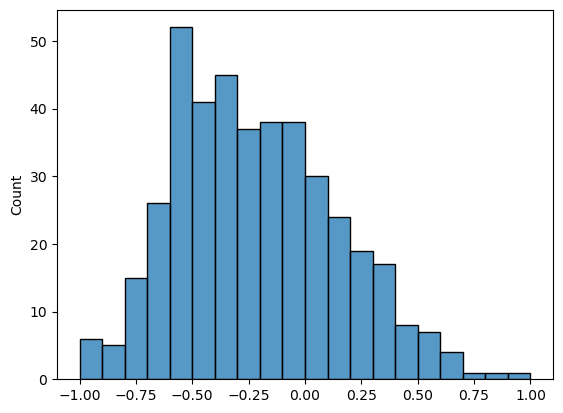

In [56]:
sns.histplot(data_train.aff_Vals,bins=20)

222

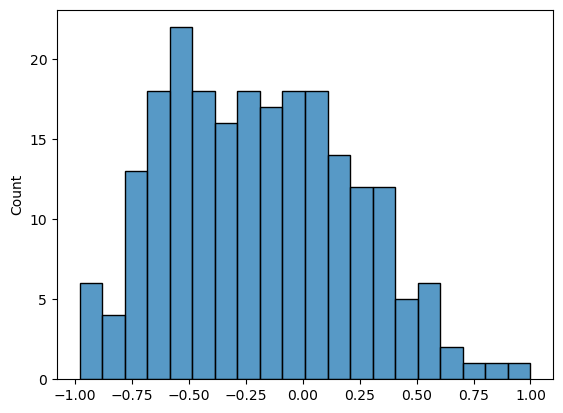

In [62]:
t = select_uniformly_distributed_subset_max_data(data_train.aff_Vals,500)
sns.histplot(t,bins=20)
len(t)

### two way ~ modified and which will be used for actual model training

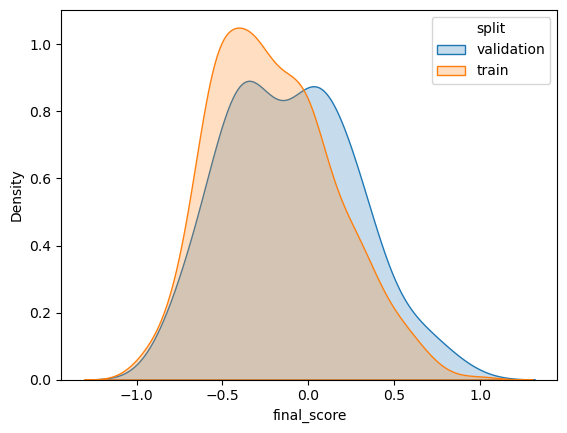

In [40]:
train_csv = pd.read_csv('../../data/ppi_affinity_dataset/raw/training.csv')
test_csv = pd.read_csv('../../data/ppi_affinity_dataset/raw/test.csv')
validation_csv = pd.read_csv('../../data/ppi_affinity_dataset/raw/validation.csv')

data_csv = {'train_csv':pd.concat([train_csv,test_csv]),
            'validation_csv':validation_csv,
            }

new_df = {}
for idx in data_csv.keys():
    seq_prot = [x.split('-')[0] for x in list(data_csv[idx]['Sequence'])]
    seq_pept = [x.split('-')[1] for x in list(data_csv[idx]['Sequence'])]
    energies = data_csv[idx]['delta_G']
    new_df[idx] =pd.DataFrame({'Energy':energies,
                                 'Prot_Seq':seq_prot,
                                 'Pept_Seq':seq_pept})
new_df['train_csv'][['Energy']] = new_df['train_csv'][['Energy']] * -1

new_df['validation_csv'][['Energy']] = new_df['validation_csv'][['Energy']] * -1
scaler = MinMaxScaler(feature_range=(-1,1))
new_df['train_csv']['Energy']= scaler.fit_transform(new_df['train_csv'][['Energy']])
new_df['validation_csv']['Energy']= scaler.transform(new_df['validation_csv'][['Energy']])



for idx in new_df.keys():
    new_df[idx].to_csv(f'../../data/ppi_affinity_dataset/cosine_sim_scaled/two_way/{str(idx.split("_")[0])}.csv')
    
data_train = Dataset_PEPBI(
    columns=["Prot_Seq", "Pept_Seq", "Energy"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/ppi_affinity_dataset/cosine_sim_scaled/two_way/train.csv",
    transform=esm2quinox.tokenise,
)
train_loader = DataLoader(data_train, batch_size=20)

\
data_validation = Dataset_PEPBI(
    columns=["Prot_Seq", "Pept_Seq", "Energy"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/ppi_affinity_dataset/cosine_sim_scaled/two_way/validation.csv",
    transform=esm2quinox.tokenise,
)
validation_loader = DataLoader(data_validation, batch_size=1)



sns.kdeplot(data_validation.aff_Vals, fill=True, label="validation")
sns.kdeplot(data_train.aff_Vals, fill=True, label="train")

plt.legend(title="split")
plt.xlabel("final_score")
plt.ylabel("Density")
plt.show()

-0.06131580993617435
61


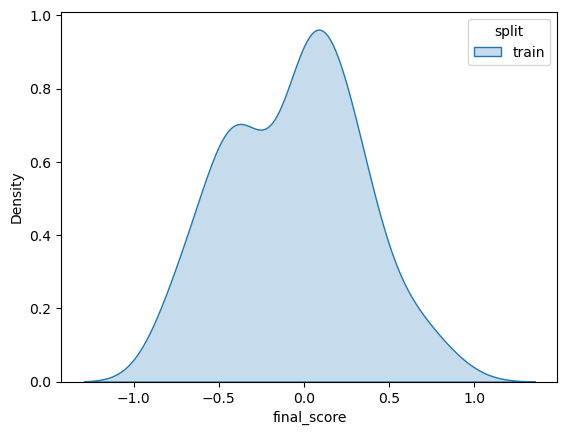

In [49]:
data_train = Dataset_PEPBI(
    columns=["Prot_Seq", "Pept_Seq", "Energy"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/ppi_affinity_dataset/cosine_sim_scaled/two_way_modified/train.csv",
    transform=esm2quinox.tokenise,
)
train_loader = DataLoader(data_train, batch_size=20)

\
data_validation = Dataset_PEPBI(
    columns=["Prot_Seq", "Pept_Seq", "Energy"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/ppi_affinity_dataset/cosine_sim_scaled/two_way_modified/validation.csv",
    transform=esm2quinox.tokenise,
)
validation_loader = DataLoader(data_validation, batch_size=1)

sns.kdeplot(data_validation.aff_Vals, fill=True, label="train")

print(np.mean(data_validation.aff_Vals))
print(len(data_validation.aff_Vals))

plt.legend(title="split")
plt.xlabel("final_score")
plt.ylabel("Density")
plt.show()